## Breast cancer classification from US images and histology images

In [ ]:

!unzip /content/DataZIP.zip -d /content/

Archive:  /content/DataZIP.zip
   creating: /content/Data/
   creating: /content/Data/benign/
   creating: /content/Data/benign/benign1/
  inflating: /content/Data/benign/benign1/us1.bmp  
  inflating: /content/Data/benign/benign1/us11.bmp  
  inflating: /content/Data/benign/benign1/us16.bmp  
  inflating: /content/Data/benign/benign1/us21.bmp  
  inflating: /content/Data/benign/benign1/us26.bmp  
  inflating: /content/Data/benign/benign1/us31.bmp  
  inflating: /content/Data/benign/benign1/us36.bmp  
  inflating: /content/Data/benign/benign1/us41.bmp  
  inflating: /content/Data/benign/benign1/us46.bmp  
  inflating: /content/Data/benign/benign1/us51.bmp  
  inflating: /content/Data/benign/benign1/us56.bmp  
  inflating: /content/Data/benign/benign1/us6.bmp  
  inflating: /content/Data/benign/benign1/us61.bmp  
  inflating: /content/Data/benign/benign1/us66.bmp  
  inflating: /content/Data/benign/benign1/us71.bmp  
  inflating: /content/Data/benign/benign1/us76.bmp  
  inflating: /con

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import shutil
import pandas as pd
import hashlib
import matplotlib.pyplot as plt
import glob
import numpy as np
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.utils.class_weight import compute_class_weight
#matplotlib.use('Agg')
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              f1_score, recall_score)
from tensorflow.keras.models import load_model
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
import matplotlib.gridspec as gridspec
from IPython.display import clear_output

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
CLASS_NAMES = ['benign', 'malignant']
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
data_base_path = '/content/Data/'

print("Searching for and deleting masked images...")
deleted_count = 0

for root, _, files in os.walk(data_base_path):
    for file in files:
        if "mask" in file.lower() and file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            file_path = os.path.join(root, file)
            try:
                os.remove(file_path)
                print(f"Deleted masked image: {file_path}")
                deleted_count += 1
            except Exception as e:
                print(f"Error deleting {file_path}: {e}")

print(f"Finished deleting. Total masked images removed: {deleted_count}")

Searching for and deleting masked images...
Deleted masked image: /content/Data/normal/normal (114)_mask.png
Deleted masked image: /content/Data/normal/normal (56)_mask.png
Deleted masked image: /content/Data/normal/normal (30)_mask.png
Deleted masked image: /content/Data/normal/normal (78)_mask.png
Deleted masked image: /content/Data/normal/normal (39)_mask.png
Deleted masked image: /content/Data/normal/normal (38)_mask.png
Deleted masked image: /content/Data/normal/normal (89)_mask.png
Deleted masked image: /content/Data/normal/normal (92)_mask.png
Deleted masked image: /content/Data/normal/normal (5)_mask.png
Deleted masked image: /content/Data/normal/normal (80)_mask.png
Deleted masked image: /content/Data/normal/normal (121)_mask.png
Deleted masked image: /content/Data/normal/normal (106)_mask.png
Deleted masked image: /content/Data/normal/normal (74)_mask.png
Deleted masked image: /content/Data/normal/normal (67)_mask.png
Deleted masked image: /content/Data/normal/normal (102)_ma

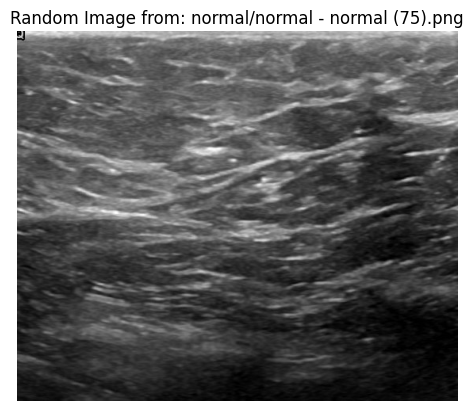

Successfully loaded and displayed: /content/Data/normal/normal (75).png


In [ ]:
data_base_path = '/content/Data/'

categories = [d for d in os.listdir(data_base_path) if os.path.isdir(os.path.join(data_base_path, d))]

if not categories:
    print(f"No categories found in {data_base_path}. Please check your unzipping process and paths.")
else:
    random_category = random.choice(categories)
    category_path = os.path.join(data_base_path, random_category)
    subfolders = [d for d in os.listdir(category_path) if os.path.isdir(os.path.join(category_path, d))]

    if subfolders:
        chosen_path = os.path.join(category_path, random.choice(subfolders))
    else:
        chosen_path = category_path
    image_files = [f for f in os.listdir(chosen_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    if not image_files:
        print(f"No image files found in {chosen_path}.")
    else:
        random_image_file = random.choice(image_files)
        image_path = os.path.join(chosen_path, random_image_file)
        try:
            img = Image.open(image_path)
            plt.imshow(img, cmap='gray')
            plt.title(f"Random Image from: {random_category}/{os.path.basename(chosen_path)} - {random_image_file}")
            plt.axis('off')
            plt.show()
            print(f"Successfully loaded and displayed: {image_path}")
        except Exception as e:
            print(f"Error loading or displaying image {image_path}: {e}")

## 3.1. Creating Train and Validation Directories and Splitting Data

In [ ]:
data_base_path = '/content/Data/'

kfold_data_dir = os.path.join(data_base_path, 'kfold_data')
test_dir = os.path.join(data_base_path, 'test')

kfold_ratio = 0.85

SPLIT_SEED = 42
random.seed(SPLIT_SEED)
already_split = (
    os.path.exists(kfold_data_dir) and os.path.exists(test_dir)
    and any(os.scandir(kfold_data_dir)) and any(os.scandir(test_dir))
)

if already_split:
    print("kfold_data/ and test/ already exist — skipping re-split to keep")
    print("the test set fixed and reproducible across notebook runs.")
    print(f"  KFOLD_DATA_DIR: {kfold_data_dir}")
    print(f"  TEST_DIR      : {test_dir}")
    print("\nIf you genuinely want to re-split (e.g. new raw data added),")
    print("delete kfold_data/ and test/ manually first, then re-run this cell.")
else:
    for directory in [kfold_data_dir, test_dir]:
        if os.path.exists(directory):
            print(f"Removing existing directory: {directory}")
            shutil.rmtree(directory)

    normal_data_path = os.path.join(data_base_path, 'normal')
    if os.path.exists(normal_data_path):
        print(f"Removing existing normal class directory: {normal_data_path}")
        shutil.rmtree(normal_data_path)
    for directory in [kfold_data_dir, test_dir]:
        os.makedirs(directory)
        print(f"Created directory: {directory}")
    print("Preparing data for K-fold cross-validation and a separate test set...")
    for category_name in CLASS_NAMES:
        print(f"Processing category: {category_name}")
        original_category_path = os.path.join(data_base_path, category_name)
        if not os.path.exists(original_category_path):
            print(f"Warning: Original category directory not found: {original_category_path}. Skipping.")
            continue
        kfold_category_path = os.path.join(kfold_data_dir, category_name)
        test_category_path = os.path.join(test_dir, category_name)

        for path in [kfold_category_path, test_category_path]:
            if not os.path.exists(path):
                os.makedirs(path)
                print(f"Created class subdirectory: {path}")

        all_files = []

        for root, _, files in os.walk(original_category_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    all_files.append(os.path.join(root, file))
        all_files.sort()
        random.shuffle(all_files)

        num_total_files = len(all_files)
        if num_total_files == 0:
            print(f"No image files found for category {category_name} in {original_category_path}. Skipping split for this category.")
            continue

        num_kfold = int(num_total_files * kfold_ratio)

        kfold_files = all_files[:num_kfold]
        test_files = all_files[num_kfold:]

        print(f"Splitting {category_name} data...")
        for file_path in kfold_files:
            shutil.copy(file_path, os.path.join(kfold_category_path, os.path.basename(file_path)))

        for file_path in test_files:
            shutil.copy(file_path, os.path.join(test_category_path, os.path.basename(file_path)))

        print(f"Moved {len(kfold_files)} {category_name} images to kfold_data.")
        print(f"  Sample kfold_data files: {[os.path.basename(f) for f in kfold_files[:5]]}")
        kfold_file_names_str = '\n'.join(sorted([os.path.basename(f) for f in kfold_files]))
        kfold_hash = hashlib.sha256(kfold_file_names_str.encode()).hexdigest()
        print(f"  Kfold data files hash: {kfold_hash}")

        print(f"Moved {len(test_files)} {category_name} images to test.")
        print(f"  Sample test files: {[os.path.basename(f) for f in test_files[:5]]}")

        test_file_names_str = '\n'.join(sorted([os.path.basename(f) for f in test_files]))
        test_hash = hashlib.sha256(test_file_names_str.encode()).hexdigest()
        print(f"  Test data files hash: {test_hash}")

    print("Data split complete for K-fold and Test sets!")

KFOLD_DATA_DIR = kfold_data_dir
TEST_DIR = test_dir
TRAIN_DIR = KFOLD_DATA_DIR

print(f"KFOLD_DATA_DIR is now set to: {KFOLD_DATA_DIR}")
print(f"TEST_DIR is now set to: {TEST_DIR}")


Removing existing normal class directory: /content/Data/normal
Created directory: /content/Data/kfold_data
Created directory: /content/Data/test
Preparing data for K-fold cross-validation and a separate test set...
Processing category: benign
Created class subdirectory: /content/Data/kfold_data/benign
Created class subdirectory: /content/Data/test/benign
Splitting benign data...
Moved 388 benign images to kfold_data.
  Sample kfold_data files: ['benign (21).png', 'benign (403).png', 'benign (391).png', 'benign (22).png', 'benign (48).png']
  Kfold data files hash: a0a4dcaa59c8fe4deccbeca5c34fae45b07553f426207f8b33a7f927fcc0dc49
Moved 69 benign images to test.
  Sample test files: ['benign (347).png', 'benign (248).png', 'benign (366).png', 'benign (370).png', 'benign (216).png']
  Test data files hash: c304150e626faf6c6a2b67f2bbdbc91f2d3de28ae78dd1fd05e0fe0c1f256e2c
Processing category: malignant
Created class subdirectory: /content/Data/kfold_data/malignant
Created class subdirectory:

### Verifying Data Splits: Sample Images


Displaying sample images from kfold_data and test directories...

Category: benign
  388 images found in kfold_data/benign/


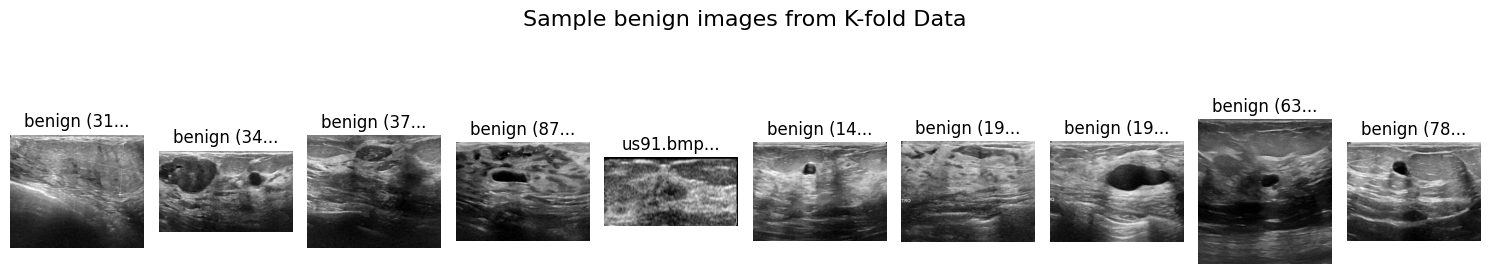

  69 images found in test/benign/


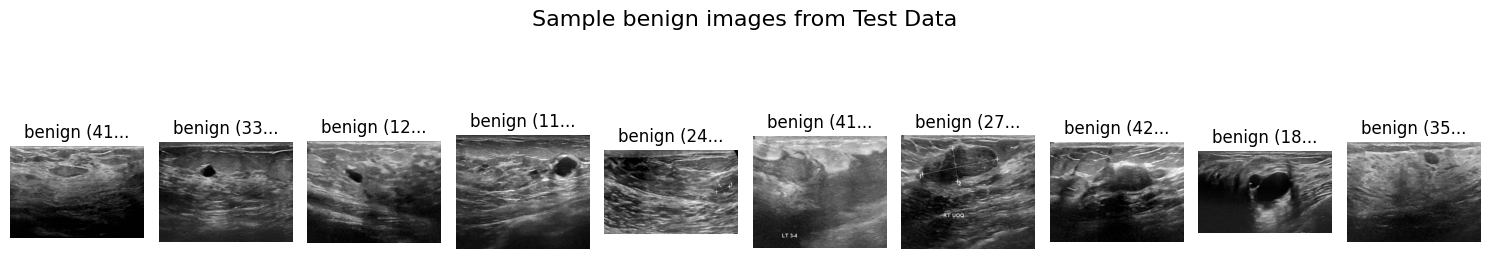


Category: malignant
  202 images found in kfold_data/malignant/


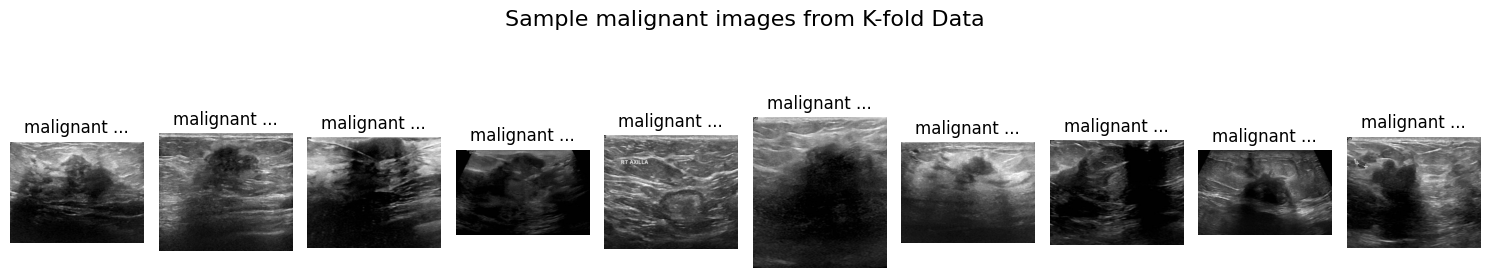

  36 images found in test/malignant/


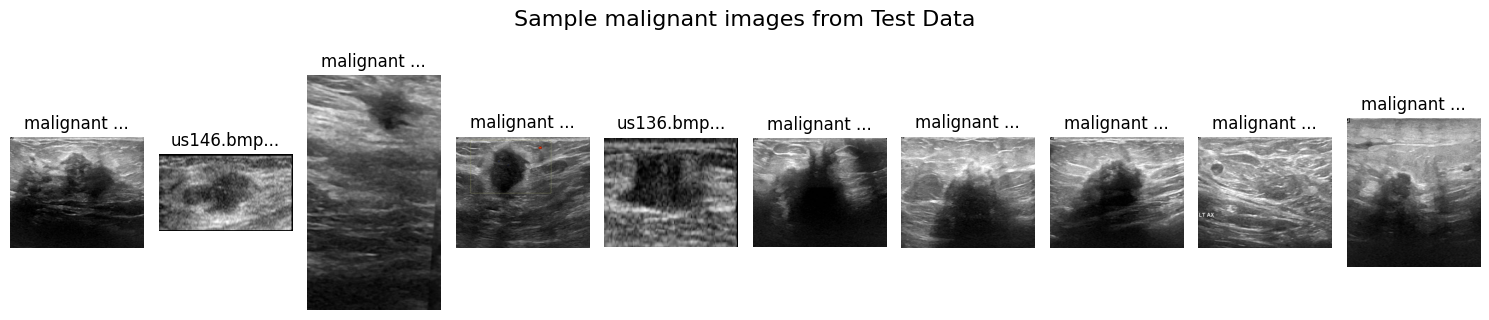

Sample image display complete.


In [ ]:
num_samples_to_display = 10

print("Displaying sample images from kfold_data and test directories...")

for category_name in CLASS_NAMES:
    print(f"\nCategory: {category_name}")

    kfold_category_path = os.path.join(KFOLD_DATA_DIR, category_name)
    kfold_image_files = glob.glob(os.path.join(kfold_category_path, '*'))
    random.shuffle(kfold_image_files) # Shuffle to get diverse samples

    print(f"  {len(kfold_image_files)} images found in kfold_data/{category_name}/")
    plt.figure(figsize=(15, 3))
    plt.suptitle(f'Sample {category_name} images from K-fold Data', fontsize=16, y=1.05)
    for i, img_path in enumerate(kfold_image_files[:num_samples_to_display]):
        plt.subplot(1, num_samples_to_display, i + 1)
        img = Image.open(img_path)
        plt.imshow(img, cmap='gray')
        plt.title(os.path.basename(img_path)[:10] + '...')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    test_category_path = os.path.join(TEST_DIR, category_name)
    test_image_files = glob.glob(os.path.join(test_category_path, '*'))
    random.shuffle(test_image_files) # Shuffle to get diverse samples

    print(f"  {len(test_image_files)} images found in test/{category_name}/")
    plt.figure(figsize=(15, 3))
    plt.suptitle(f'Sample {category_name} images from Test Data', fontsize=16, y=1.05)
    for i, img_path in enumerate(test_image_files[:num_samples_to_display]):
        plt.subplot(1, num_samples_to_display, i + 1)
        img = Image.open(img_path)
        plt.imshow(img, cmap='gray')
        plt.title(os.path.basename(img_path)[:10] + '...')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Sample image display complete.")

### Class Distribution check


Train (K-fold pool) class distribution: {'benign': 388, 'malignant': 202}
Test class distribution               : {'benign': 69, 'malignant': 36}
Saved: /content/class_distribution.png


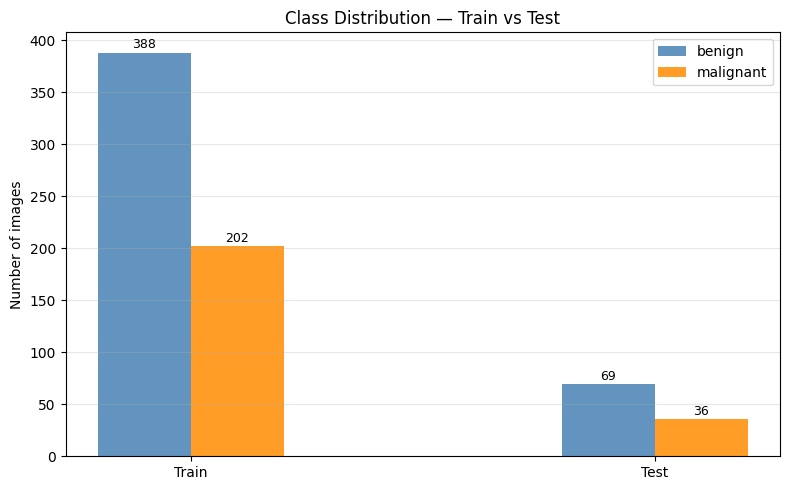

In [ ]:
def count_images_per_class(base_dir, class_names):
    counts = {}
    for cls in class_names:
        cls_dir = os.path.join(base_dir, cls)
        if os.path.exists(cls_dir):
            counts[cls] = len([
                f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))
            ])
        else:
            counts[cls] = 0
    return counts

train_counts = count_images_per_class(KFOLD_DATA_DIR, CLASS_NAMES)
test_counts  = count_images_per_class(TEST_DIR, CLASS_NAMES)

print("Train (K-fold pool) class distribution:", train_counts)
print("Test class distribution               :", test_counts)


groups = ['Train', 'Test']
x = np.arange(len(groups))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'darkorange']
bars_list = []
for i, cls in enumerate(CLASS_NAMES):

    vals = [train_counts.get(cls, 0), test_counts.get(cls, 0)]
    pos = x - width/2 + i * width
    b = ax.bar(pos, vals, width, label=cls, color=colors[i % len(colors)], alpha=0.85)
    bars_list.append(b)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Number of images')
ax.set_title('Class Distribution — Train vs Test')
ax.legend()
ax.grid(axis='y', alpha=0.3)
all_vals = [train_counts.get(c, 0) for c in CLASS_NAMES] + [test_counts.get(c, 0) for c in CLASS_NAMES]
max_val = max(all_vals) if all_vals else 1

for bars in bars_list:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max_val * 0.01,
                f'{int(h)}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
print("Saved: /content/class_distribution.png")

In [ ]:
NFOLDS = 5
kf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=42)

print(f"StratifiedKFold initialized with {NFOLDS} splits.")


StratifiedKFold initialized with 5 splits.


## 2. ResNet-50 Model with Custom Classification Head



In [ ]:
NUM_CLASSES = 2
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = BATCH_SIZE

def build_model(apply_regularization=True, apply_dropout=True, label_smoothing=0.05, l2_strength=0.001):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    # Freeze all layers first
    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[143:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    if apply_regularization:
        x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_strength))(x)
    else:
        x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    if apply_dropout:
        x = Dropout(0.5)(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss_fn,
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

test_model = build_model()
trainable = sum(1 for l in test_model.layers if l.trainable)
total     = len(test_model.layers)
print(f"Trainable layers: {trainable}/{total}")
print(f"Output shape: {test_model.output_shape}")
del test_model


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable layers: 27/180
Output shape: (None, 1)


## 3. Data Loading and Augmentation


In [ ]:
TRAIN_DIR = '/content/Data/kfold_data'
VAL_DIR   = '/content/Data/test'
TEST_DIR  = '/content/Data/test'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=CLASS_NAMES
)

print('Class indices:', train_generator.class_indices)

Found 590 images belonging to 2 classes.
Found 105 images belonging to 2 classes.
Found 105 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


## 3.5 Sanity Check: Overfit a small subset



Tiny subset: 12 images (benign: 6, malignant: 6)
Found 9 validated image filenames belonging to 2 classes.
Found 3 validated image filenames belonging to 2 classes.
Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 27s 27s/step - accuracy: 0.3333 - auc: 0.4000 - loss: 0.8100 - precision: 0.4000 - recall: 0.4000 - val_accuracy: 0.6667 - val_auc: 0.7500 - val_loss: 0.5538 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1390 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.6667 - val_auc: 1.0000 - val_loss: 0.5743 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1228 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.6667 - val_auc: 1.0000 - val_loss: 0.6184 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1251 - precisio

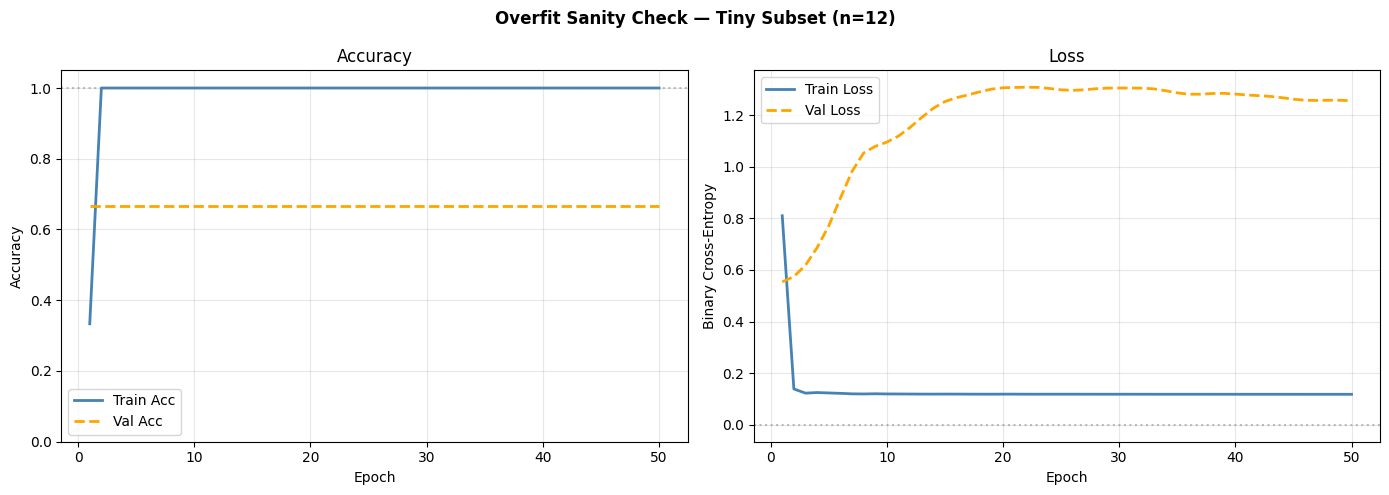

Saved: /content/overfit_sanity_check.png

Final train loss: 0.1183  |  Final train accuracy: 1.0000
Model can memorize a tiny subset -> pipeline looks healthy. Proceed to full K-fold training.


In [ ]:
TINY_SUBSET_SIZE = 12
OVERFIT_EPOCHS   = 50

_tiny_paths, _tiny_labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(KFOLD_DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            _tiny_paths.append(os.path.join(cls_dir, fname))
            _tiny_labels.append(label_idx)
_tiny_paths  = np.array(_tiny_paths)
_tiny_labels = np.array(_tiny_labels)

rng = np.random.RandomState(42)
tiny_idx = []
per_class = max(1, TINY_SUBSET_SIZE // NUM_CLASSES)
for label_idx in range(NUM_CLASSES):
    cls_idx = np.where(_tiny_labels == label_idx)[0]
    chosen  = rng.choice(cls_idx, size=min(per_class, len(cls_idx)), replace=False)
    tiny_idx.extend(chosen)
tiny_idx = np.array(tiny_idx)

tiny_paths  = _tiny_paths[tiny_idx]
tiny_labels = _tiny_labels[tiny_idx]

print(f"Tiny subset: {len(tiny_paths)} images "
      f"(benign: {(tiny_labels==0).sum()}, malignant: {(tiny_labels==1).sum()})")

if len(tiny_paths) >= 4:
    tp_train, tp_val, tl_train, tl_val = train_test_split(
        tiny_paths, tiny_labels, test_size=0.25,
        stratify=tiny_labels if len(np.unique(tiny_labels)) > 1 else None,
        random_state=42
    )
else:
    tp_train, tp_val, tl_train, tl_val = tiny_paths, tiny_paths, tiny_labels, tiny_labels

tiny_train_df = pd.DataFrame({'filename': tp_train, 'class': [CLASS_NAMES[l] for l in tl_train]})
tiny_val_df   = pd.DataFrame({'filename': tp_val,   'class': [CLASS_NAMES[l] for l in tl_val]})

tiny_train_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    tiny_train_df, x_col='filename', y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=min(BATCH_SIZE, len(tp_train)),
    class_mode='binary', classes=CLASS_NAMES, shuffle=True
)
tiny_val_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    tiny_val_df, x_col='filename', y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=min(BATCH_SIZE, len(tp_val)),
    class_mode='binary', classes=CLASS_NAMES, shuffle=False
)

overfit_model = build_model(apply_regularization=False, apply_dropout=False)
overfit_history = overfit_model.fit(
    tiny_train_gen,
    validation_data=tiny_val_gen,
    epochs=OVERFIT_EPOCHS,
    verbose=1
)

epochs_ran = range(1, len(overfit_history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Overfit Sanity Check — Tiny Subset (n={len(tiny_paths)})', fontweight='bold')

axes[0].plot(epochs_ran, overfit_history.history['accuracy'],     label='Train Acc', color='steelblue', lw=2)
axes[0].plot(epochs_ran, overfit_history.history['val_accuracy'], label='Val Acc',   color='orange', linestyle='--', lw=2)
axes[0].axhline(1.0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, overfit_history.history['loss'],     label='Train Loss', color='steelblue', lw=2)
axes[1].plot(epochs_ran, overfit_history.history['val_loss'], label='Val Loss',   color='orange', linestyle='--', lw=2)
axes[1].axhline(0.0, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/overfit_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/overfit_sanity_check.png")

final_train_loss_tiny = overfit_history.history['loss'][-1]
final_train_acc_tiny  = overfit_history.history['accuracy'][-1]
print(f"\nFinal train loss: {final_train_loss_tiny:.4f}  |  Final train accuracy: {final_train_acc_tiny:.4f}")
if final_train_acc_tiny > 0.95 and final_train_loss_tiny < 0.12:
    print("Model can memorize a tiny subset -> pipeline looks healthy. Proceed to full K-fold training.")
else:
    print("Model did NOT reach near-perfect memorization. Check labels, generator, "
          "architecture, or learning rate before running the full K-fold training.")

del overfit_model
tf.keras.backend.clear_session()

## 4. K-Fold Cross-Validation Training

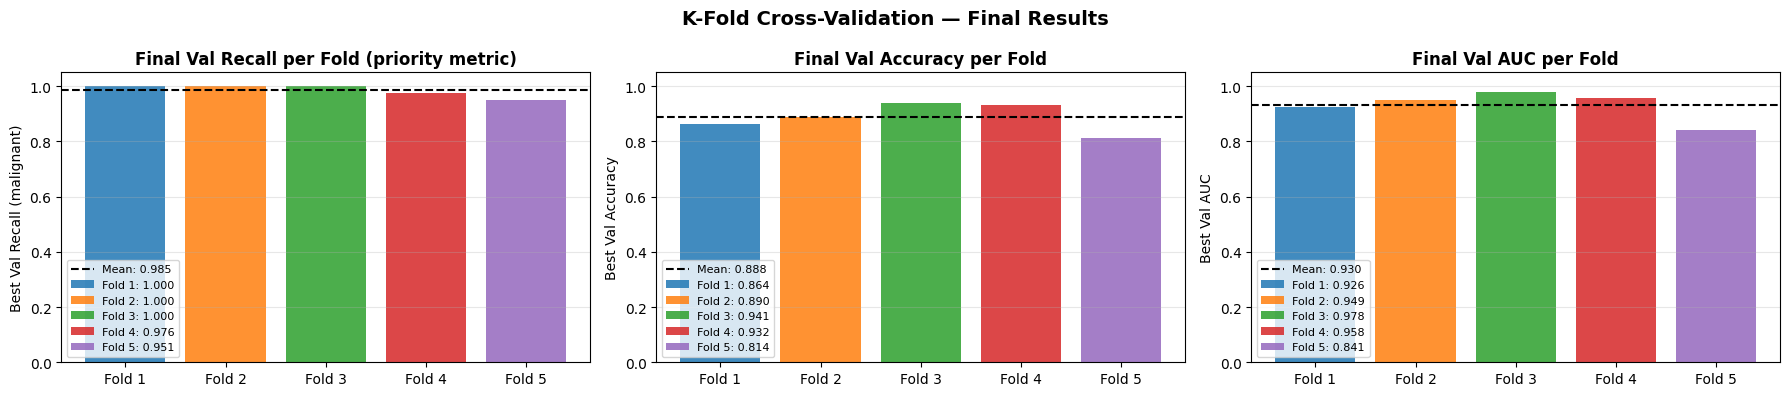


K-fold training complete.
 fold  val_acc  val_auc   val_f1  val_f1_benign  val_f1_malignant  val_recall  val_recall_benign  val_recall_malignant
    1 0.864407 0.926122 0.808841       0.859060          0.758621    1.000000           0.820513              0.825000
    2 0.889831 0.949359 0.876320       0.917197          0.835443    1.000000           0.923077              0.825000
    3 0.940678 0.977564 0.893980       0.930818          0.857143    1.000000           0.948718              0.825000
    4 0.932203 0.958347 0.923401       0.949367          0.897436    0.975610           0.974026              0.853659
    5 0.813559 0.840988 0.696611       0.781457          0.611765    0.951219           0.766234              0.634146

Mean val Recall (malignant) : 0.9854 ± 0.0218   <-- priority metric
Mean val Accuracy            : 0.8881 ± 0.0520
Mean val AUC                 : 0.9305 ± 0.0533
Mean val F1 (macro)          : 0.8398 ± 0.0904


In [ ]:

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE  = BATCH_SIZE
NFOLDS      = 5
EPOCHS      = 40 # Increased epochs
CLASS_NAMES = ['benign', 'malignant']

KFOLD_DATA_DIR = '/content/Data/kfold_data'
TEST_DIR       = '/content/Data/test'

all_paths, all_labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(KFOLD_DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(label_idx)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"Total K-fold images: {len(all_paths)}")
print(f"  benign: {(all_labels==0).sum()}  |  malignant: {(all_labels==1).sum()}")

def make_generators(train_paths, train_labels, val_paths, val_labels):
    train_df = pd.DataFrame({'filename': train_paths,
                              'class':    [CLASS_NAMES[l] for l in train_labels]})
    val_df   = pd.DataFrame({'filename': val_paths,
                              'class':    [CLASS_NAMES[l] for l in val_labels]})

    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    ).flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASS_NAMES,
        shuffle=True
    )
    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    ).flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASS_NAMES,
        shuffle=False
    )
    return train_gen, val_gen

class LiveCVDashboard(Callback):

    def __init__(self, fold_idx, nfolds, fold_val_metrics):
        super().__init__()
        self.fold_idx        = fold_idx
        self.nfolds          = nfolds
        self.fold_val_metrics = fold_val_metrics
        self.epoch_accs      = []   # val_accuracy for current fold, per epoch
        self.epoch_aucs      = []   # val_auc for current fold, per epoch
        self.epoch_recalls   = []   # val_recall (malignant) for current fold, per epoch — priority metric

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epoch_accs.append(logs.get('val_accuracy', 0))
        self.epoch_aucs.append(logs.get('val_auc', 0))
        self.epoch_recalls.append(logs.get('val_recall', 0))

        clear_output(wait=True)

        fig = plt.figure(figsize=(20, 5))
        gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.4)

        colors = plt.cm.tab10.colors

        ax0 = fig.add_subplot(gs[0])
        ax0.plot(range(1, len(self.epoch_recalls) + 1), self.epoch_recalls,
                 color='crimson', lw=2,
                 label=f'Fold {self.fold_idx+1} val recall')
        ax0.axhline(max(self.epoch_recalls), color='crimson',
                    linestyle='--', alpha=0.5,
                    label=f'Best so far: {max(self.epoch_recalls):.3f}')
        ax0.set_title(f'Fold {self.fold_idx+1}/{self.nfolds} — Val Recall (malignant) per Epoch',
                      fontweight='bold')
        ax0.set_xlabel('Epoch'); ax0.set_ylabel('Val Recall')
        ax0.set_ylim(0, 1); ax0.legend(fontsize=9); ax0.grid(alpha=0.3)

        ax1 = fig.add_subplot(gs[1])
        ax1.plot(range(1, len(self.epoch_accs) + 1), self.epoch_accs,
                 color=colors[self.fold_idx], lw=2,
                 label=f'Fold {self.fold_idx+1} val acc')
        ax1.axhline(max(self.epoch_accs), color=colors[self.fold_idx],
                    linestyle='--', alpha=0.5,
                    label=f'Best so far: {max(self.epoch_accs):.3f}')
        ax1.set_title(f'Fold {self.fold_idx+1}/{self.nfolds} — Val Accuracy per Epoch',
                      fontweight='bold')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Accuracy')
        ax1.set_ylim(0, 1); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

        ax2 = fig.add_subplot(gs[2])
        ax2.plot(range(1, len(self.epoch_aucs) + 1), self.epoch_aucs,
                 color=colors[self.fold_idx], lw=2,
                 label=f'Fold {self.fold_idx+1} val AUC')
        ax2.axhline(max(self.epoch_aucs), color=colors[self.fold_idx],
                    linestyle='--', alpha=0.5,
                    label=f'Best so far: {max(self.epoch_aucs):.3f}')
        ax2.set_title(f'Fold {self.fold_idx+1}/{self.nfolds} — Val AUC per Epoch',
                      fontweight='bold')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val AUC')
        ax2.set_ylim(0, 1); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

        ax3 = fig.add_subplot(gs[3])

        completed_labels = [f"Fold {m['fold']}" for m in self.fold_val_metrics]
        completed_accs   = [m['val_acc'] for m in self.fold_val_metrics]
        completed_cols   = [colors[m['fold']-1] for m in self.fold_val_metrics]

        current_label = f"Fold {self.fold_idx+1}\n(live)"
        current_acc   = max(self.epoch_accs)

        all_labels_bar = completed_labels + [current_label]
        all_accs_bar   = completed_accs   + [current_acc]
        all_cols_bar   = completed_cols   + [colors[self.fold_idx]]

        x_pos = range(len(all_labels_bar))
        bars = ax3.bar(x_pos, all_accs_bar, color=all_cols_bar, alpha=0.85, width=0.6)
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(all_labels_bar, fontsize=9)
        ax3.set_ylim(0, 1.05)
        ax3.set_ylabel('Best Val Accuracy')
        ax3.set_title('Accuracy Progress Across Folds', fontweight='bold')
        ax3.grid(axis='y', alpha=0.3)
        if completed_accs:
            ax3.axhline(np.mean(completed_accs + [current_acc]),
                        color='black', linestyle=':', lw=1.5,
                        label=f'Running mean: {np.mean(completed_accs + [current_acc]):.3f}')
            ax3.legend(fontsize=9)
        for bar, acc in zip(bars, all_accs_bar):
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

        fig.suptitle(
            f'K-Fold CV Live Dashboard  |  Epoch {epoch+1}  |  '
            f'Folds done: {len(self.fold_val_metrics)}/{self.nfolds}',
            fontsize=13, fontweight='bold'
        )
        plt.savefig('/content/cv_live_dashboard.png', dpi=120, bbox_inches='tight')
        plt.show()

class LRHistory(Callback):
    def __init__(self):
        super().__init__()
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        lr_value = float(lr.numpy()) if hasattr(lr, 'numpy') else float(tf.keras.backend.get_value(lr))
        self.lrs.append(lr_value)

skf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=42)

fold_histories   = []
fold_val_metrics = []

best_val_auc    = -1
best_val_recall = -1
best_model_path = '/content/best_resnet50_fold.keras'

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx+1} / {NFOLDS}  —  Train: {len(train_idx)}  |  Val: {len(val_idx)}")
    print(f"{'='*60}")

    train_gen, val_gen = make_generators(
        all_paths[train_idx], all_labels[train_idx],
        all_paths[val_idx],   all_labels[val_idx]
    )

    fold_train_labels = all_labels[train_idx]
    cw = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(fold_train_labels),
        y=fold_train_labels
    )
    class_weight_dict = {int(c): w for c, w in zip(np.unique(fold_train_labels), cw)}
    print(f"  Class weights (this fold): {class_weight_dict}")

    model = build_model()

    dashboard = LiveCVDashboard(fold_idx, NFOLDS, fold_val_metrics)
    lr_history = LRHistory()

    callbacks = [

        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, mode='min', verbose=1),
        dashboard,
        lr_history,
    ]

    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        class_weight=class_weight_dict,  # balances training loss only
        verbose=0
    )

    history.history['lr_actual'] = lr_history.lrs
    fold_histories.append(history.history)

    val_auc    = max(history.history.get('val_auc', [0]))
    val_acc    = max(history.history.get('val_accuracy', [0]))
    val_recall = max(history.history.get('val_recall', [0]))

    val_gen.reset()
    val_proba_fold = model.predict(val_gen, verbose=0).ravel()
    val_true_fold  = val_gen.classes
    val_pred_fold  = (val_proba_fold >= 0.5).astype(int)
    val_f1_macro     = f1_score(val_true_fold, val_pred_fold, average='macro')
    val_f1_perclass  = f1_score(val_true_fold, val_pred_fold, average=None)
    val_recall_perclass = recall_score(val_true_fold, val_pred_fold, average=None)

    fold_val_metrics.append({
        'fold': fold_idx+1, 'val_acc': val_acc, 'val_auc': val_auc,
        'val_f1': val_f1_macro,
        'val_f1_benign': val_f1_perclass[0], 'val_f1_malignant': val_f1_perclass[1],
        'val_recall': val_recall,  # malignant recall (priority metric)
        'val_recall_benign': val_recall_perclass[0],
        'val_recall_malignant': val_recall_perclass[1],
    })
    print(f"  Fold {fold_idx+1} best → val Recall (malignant): {val_recall:.4f}  |  "
          f"val AUC: {val_auc:.4f}  |  val Acc: {val_acc:.4f}  |  val F1 (macro): {val_f1_macro:.4f}")

    if val_recall > best_val_recall:
        best_val_recall = val_recall
        model.save(best_model_path)
        print(f"  ✓ New best model saved (val_recall={val_recall:.4f})")

    tf.keras.backend.clear_session()

clear_output(wait=True)
metrics_df = pd.DataFrame(fold_val_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = plt.cm.tab10.colors

for i, m in enumerate(fold_val_metrics):
    axes[0].bar(i, m['val_recall'], color=colors[i], alpha=0.85, label=f"Fold {m['fold']}: {m['val_recall']:.3f}")
axes[0].axhline(metrics_df['val_recall'].mean(), color='black', linestyle='--', lw=1.5,
                label=f"Mean: {metrics_df['val_recall'].mean():.3f}")
axes[0].set_xticks(range(NFOLDS))
axes[0].set_xticklabels([f"Fold {m['fold']}" for m in fold_val_metrics])
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Best Val Recall (malignant)')
axes[0].set_title('Final Val Recall per Fold (priority metric)', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

# Final accuracy per fold
for i, m in enumerate(fold_val_metrics):
    axes[1].bar(i, m['val_acc'], color=colors[i], alpha=0.85, label=f"Fold {m['fold']}: {m['val_acc']:.3f}")
axes[1].axhline(metrics_df['val_acc'].mean(), color='black', linestyle='--', lw=1.5,
                label=f"Mean: {metrics_df['val_acc'].mean():.3f}")
axes[1].set_xticks(range(NFOLDS))
axes[1].set_xticklabels([f"Fold {m['fold']}" for m in fold_val_metrics])
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('Best Val Accuracy')
axes[1].set_title('Final Val Accuracy per Fold', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

# Final AUC per fold
for i, m in enumerate(fold_val_metrics):
    axes[2].bar(i, m['val_auc'], color=colors[i], alpha=0.85, label=f"Fold {m['fold']}: {m['val_auc']:.3f}")
axes[2].axhline(metrics_df['val_auc'].mean(), color='black', linestyle='--', lw=1.5,
                label=f"Mean: {metrics_df['val_auc'].mean():.3f}")
axes[2].set_xticks(range(NFOLDS))
axes[2].set_xticklabels([f"Fold {m['fold']}" for m in fold_val_metrics])
axes[2].set_ylim(0, 1.05); axes[2].set_ylabel('Best Val AUC')
axes[2].set_title('Final Val AUC per Fold', fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('K-Fold Cross-Validation — Final Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/kfold_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nK-fold training complete.")
print(metrics_df.to_string(index=False))
print(f"\nMean val Recall (malignant) : {metrics_df['val_recall'].mean():.4f} \u00B1 {metrics_df['val_recall'].std():.4f}   <-- priority metric")
print(f"Mean val Accuracy            : {metrics_df['val_acc'].mean():.4f} \u00B1 {metrics_df['val_acc'].std():.4f}")
print(f"Mean val AUC                 : {metrics_df['val_auc'].mean():.4f} \u00B1 {metrics_df['val_auc'].std():.4f}")
print(f"Mean val F1 (macro)          : {metrics_df['val_f1'].mean():.4f} \u00B1 {metrics_df['val_f1'].std():.4f}")


## 5. Training Curves

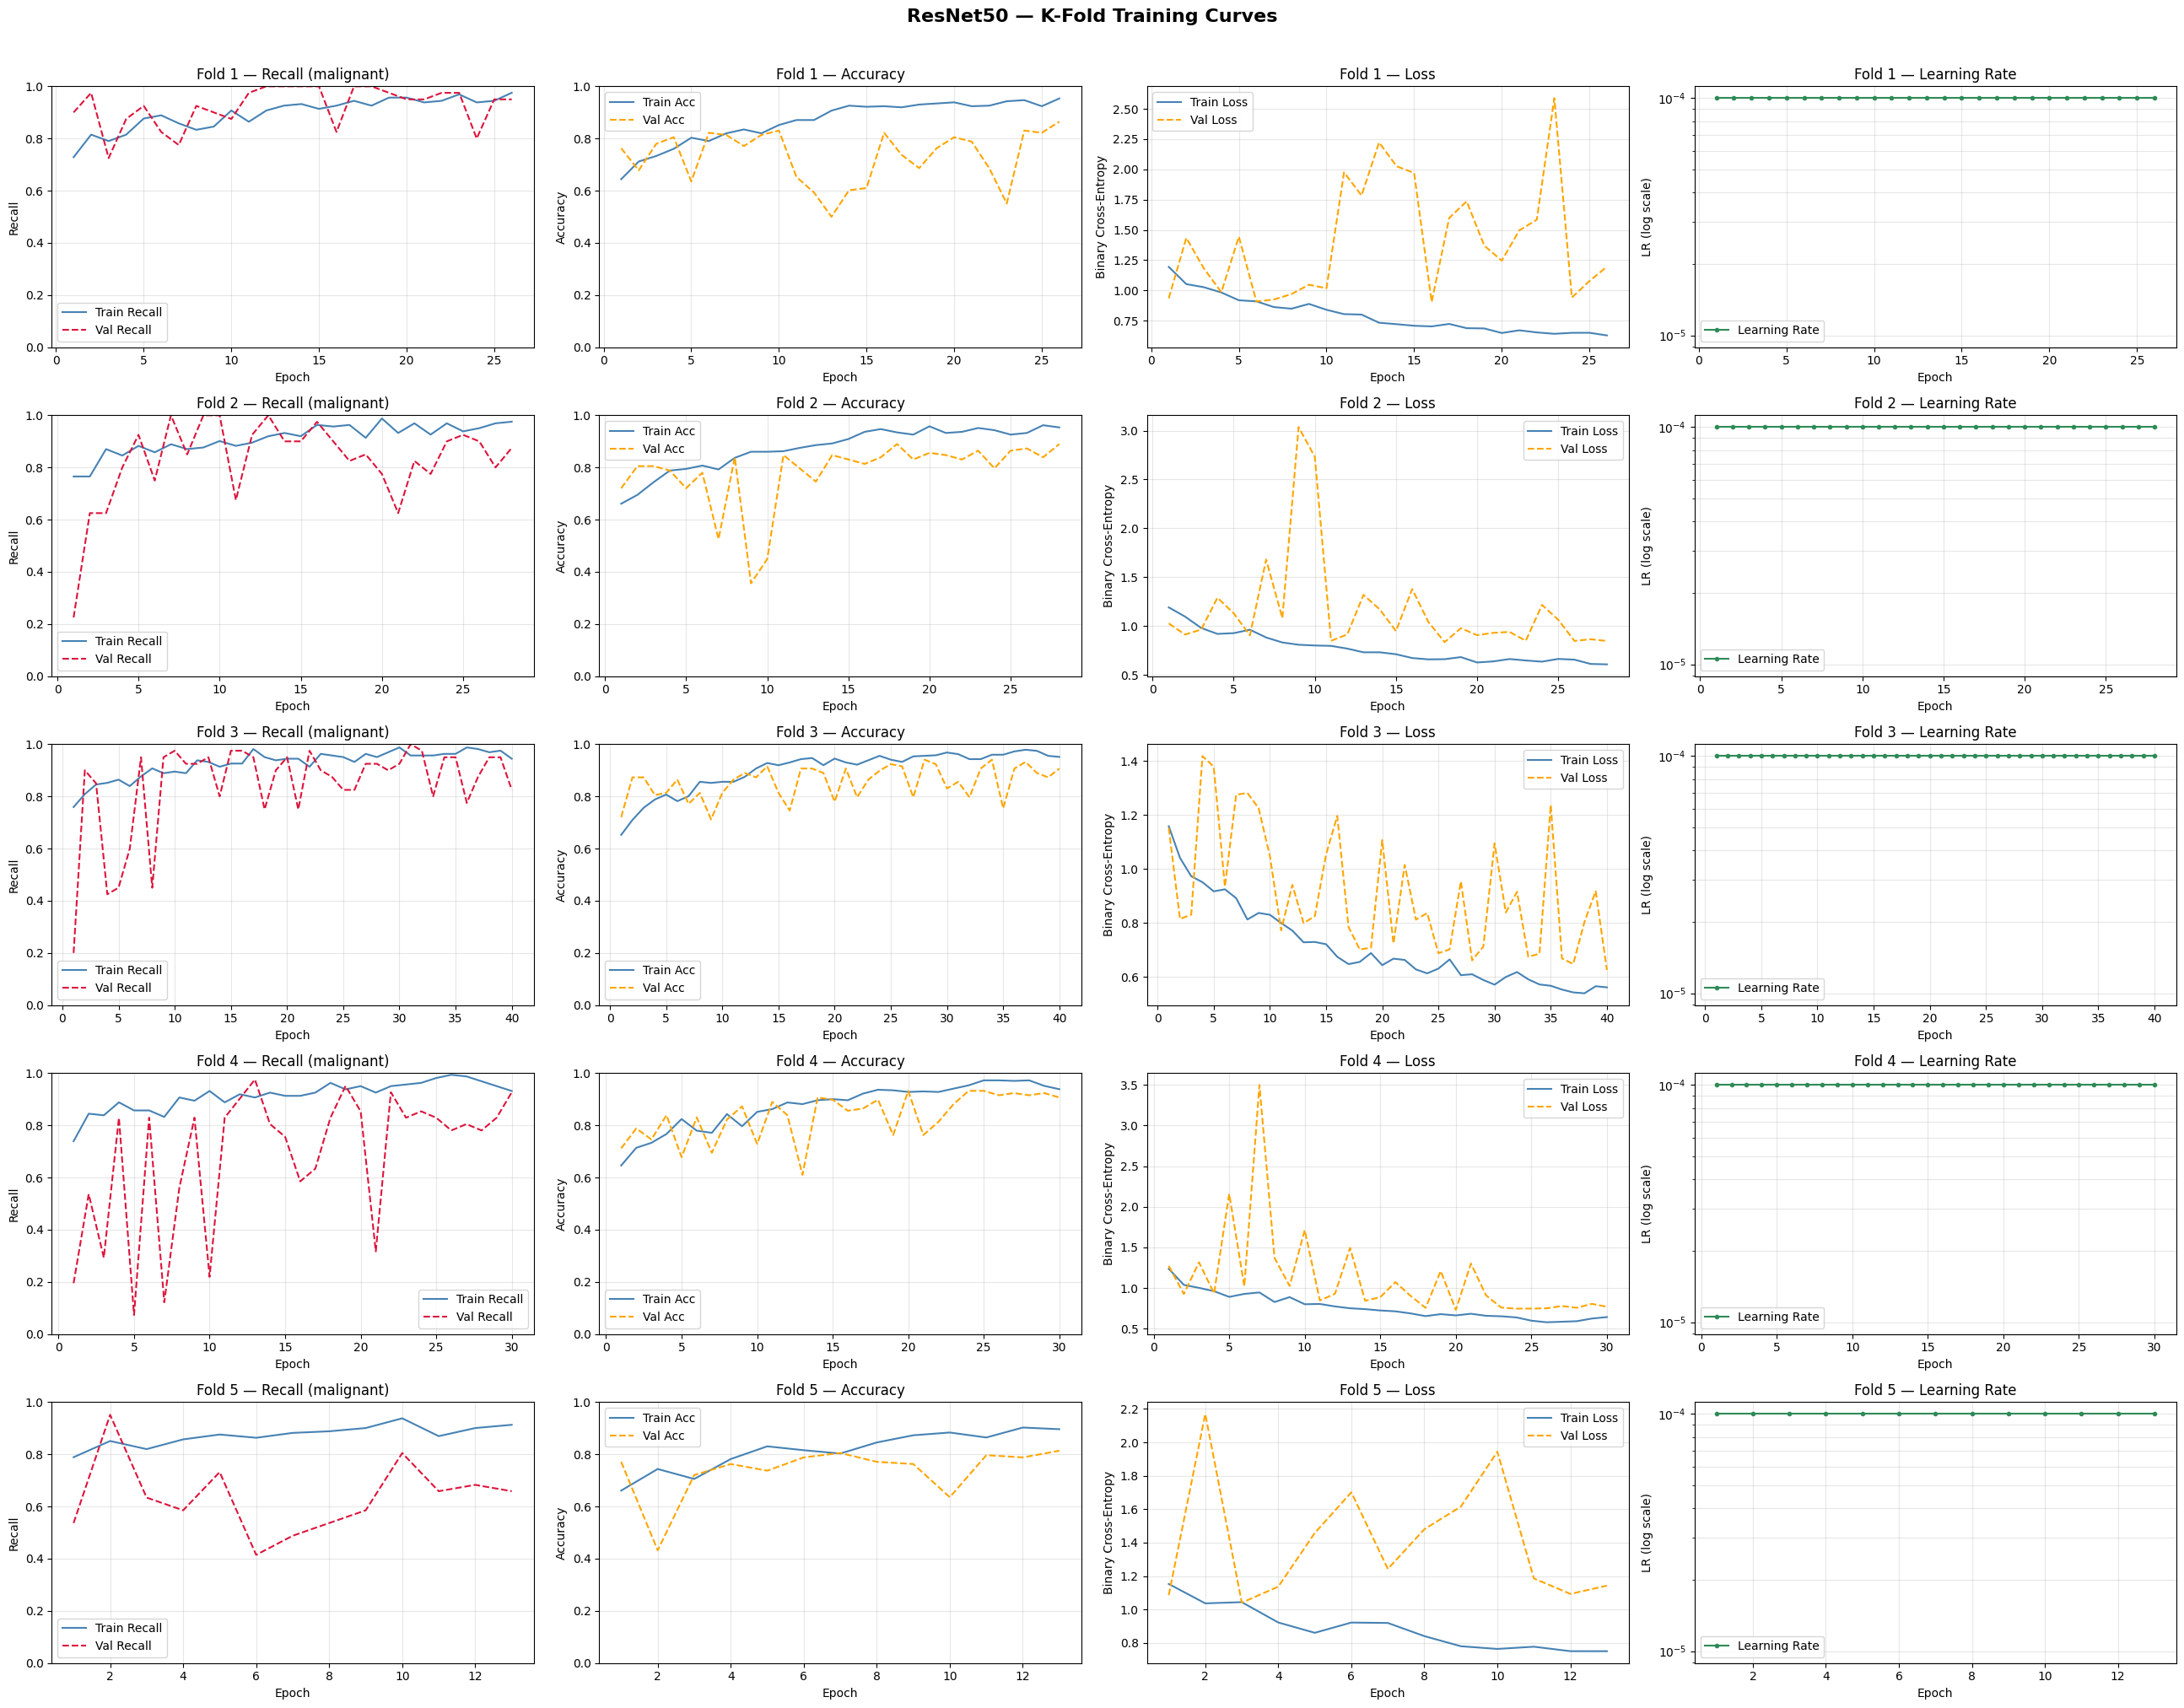

Saved: /content/training_curves.png


In [ ]:
fig, axes = plt.subplots(NFOLDS, 4, figsize=(26, 4 * NFOLDS))
fig.suptitle('ResNet50 — K-Fold Training Curves', fontsize=16, fontweight='bold', y=1.01)

for fold_idx, h in enumerate(fold_histories):
    epochs_ran = range(1, len(h['accuracy']) + 1)

    ax = axes[fold_idx, 0]
    ax.plot(epochs_ran, h['recall'],     label='Train Recall', color='steelblue')
    ax.plot(epochs_ran, h['val_recall'], label='Val Recall',   color='crimson', linestyle='--')
    ax.set_title(f'Fold {fold_idx+1} — Recall (malignant)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Recall')
    ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[fold_idx, 1]
    ax.plot(epochs_ran, h['accuracy'],     label='Train Acc',  color='steelblue')
    ax.plot(epochs_ran, h['val_accuracy'], label='Val Acc',    color='orange', linestyle='--')
    ax.set_title(f'Fold {fold_idx+1} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[fold_idx, 2]
    ax.plot(epochs_ran, h['loss'],     label='Train Loss', color='steelblue')
    ax.plot(epochs_ran, h['val_loss'], label='Val Loss',   color='orange', linestyle='--')
    ax.set_title(f'Fold {fold_idx+1} — Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[fold_idx, 3]
    ax.plot(epochs_ran, h['lr_actual'], label='Learning Rate', color='seagreen', marker='o', markersize=3)
    ax.set_yscale('log')
    ax.set_title(f'Fold {fold_idx+1} — Learning Rate')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log scale)')
    ax.legend(); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/training_curves.png")


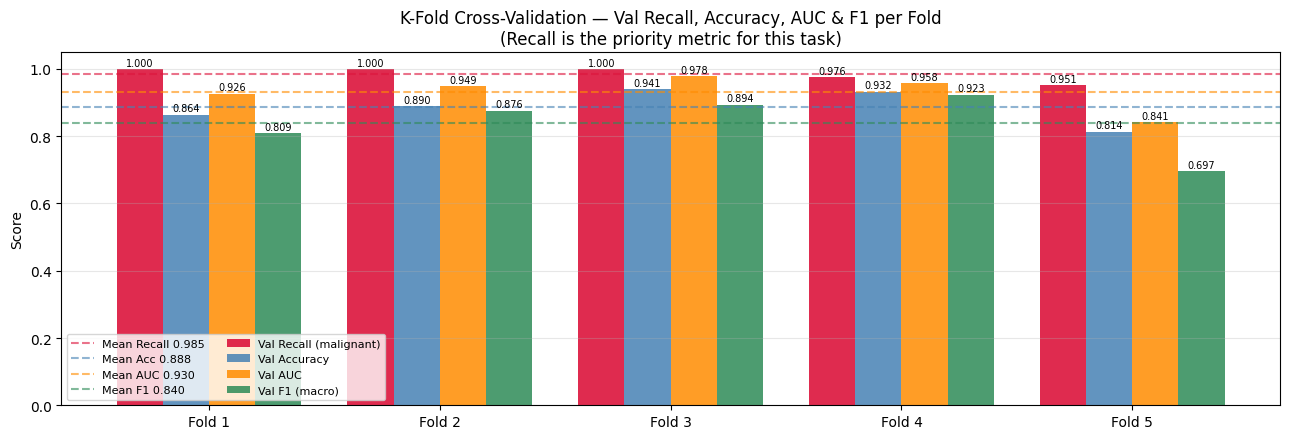

Saved: /content/kfold_summary.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.5))
folds   = [m['fold'] for m in fold_val_metrics]
recalls = [m['val_recall'] for m in fold_val_metrics]   # priority metric
accs    = [m['val_acc'] for m in fold_val_metrics]
aucs    = [m['val_auc'] for m in fold_val_metrics]
f1s     = [m['val_f1']  for m in fold_val_metrics]
x = np.arange(len(folds))
width = 0.2

bars0 = ax.bar(x - 1.5*width, recalls, width, label='Val Recall (malignant)', color='crimson',    alpha=0.9)
bars1 = ax.bar(x - 0.5*width, accs,    width, label='Val Accuracy',           color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + 0.5*width, aucs,    width, label='Val AUC',                color='darkorange', alpha=0.85)
bars3 = ax.bar(x + 1.5*width, f1s,     width, label='Val F1 (macro)',         color='seagreen',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in folds])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('K-Fold Cross-Validation — Val Recall, Accuracy, AUC & F1 per Fold\n(Recall is the priority metric for this task)')
ax.axhline(np.mean(recalls), color='crimson',    linestyle='--', alpha=0.6, label=f'Mean Recall {np.mean(recalls):.3f}')
ax.axhline(np.mean(accs),    color='steelblue',  linestyle='--', alpha=0.6, label=f'Mean Acc {np.mean(accs):.3f}')
ax.axhline(np.mean(aucs),    color='darkorange', linestyle='--', alpha=0.6, label=f'Mean AUC {np.mean(aucs):.3f}')
ax.axhline(np.mean(f1s),     color='seagreen',   linestyle='--', alpha=0.6, label=f'Mean F1 {np.mean(f1s):.3f}')
ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)

for bars in [bars0, bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/content/kfold_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/kfold_summary.png")


## 6. Retrain on Full K-Fold Data (Final Model)



Original total K-fold images: 590
  benign: 388  |  malignant: 202

Final model training data: 501 images
  benign: 329  |  malignant: 172 (for training)
Final model validation data: 89 images
  benign: 59  |  malignant: 30 (for validation)
Class weights (final retrain): {0: np.float64(0.7613981762917933), 1: np.float64(1.4563953488372092)}

Mean epochs run across folds: 27
Training final model for up to 37 epochs (with early stopping).
Found 501 validated image filenames belonging to 2 classes.
Found 89 validated image filenames belonging to 2 classes.
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6381 - auc: 0.6851 - loss: 1.2388 - precision: 0.4829 - recall: 0.6729  [epoch 1] val_precision=0.5625  val_recall=0.9000  -> F2=0.8036
16/16 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6527 - auc: 0.7322 - loss: 1.1962 - precision: 0.4959 - recall: 0.7035 - val_accuracy: 0.7303 - val_auc: 0.8836 - val_loss: 1.0583 - val_precision: 0.5625 - val_recall: 0.9000 - val_fbeta_

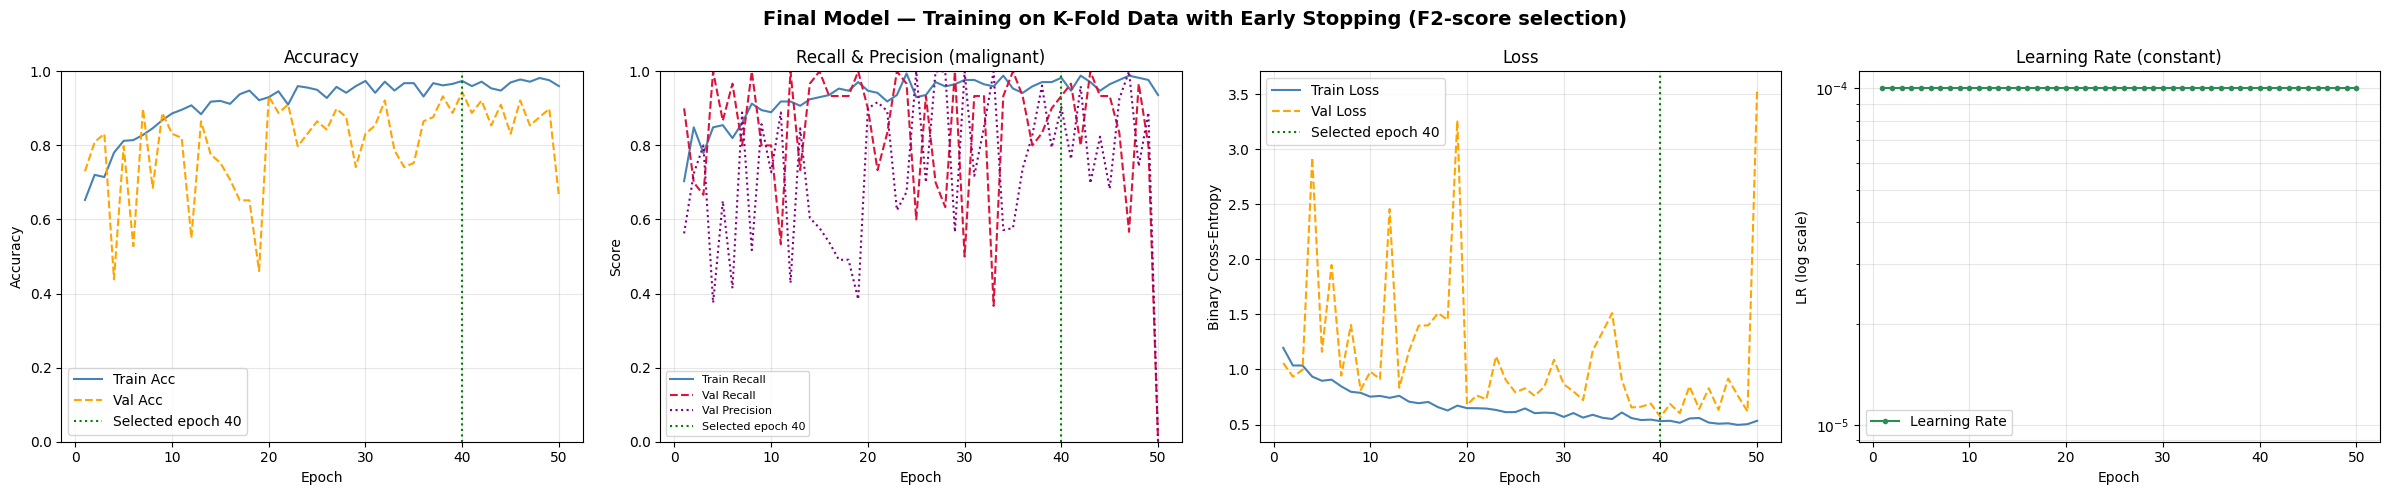

Saved: /content/final_model_training_with_val.png

  FINAL MODEL — TRAINING SUMMARY (before test set)
  Epochs run (total)  : 50
  Selected epoch      : 40  (highest F2-score = 0.9272)
  Train Accuracy      : 0.9741
  Train Loss          : 0.5306
  Validation Accuracy : 0.9438
  Validation Recall   : 0.9333
  Validation Precision: 0.9032
  Validation Loss     : 0.5685

Note: train/val metrics above are on augmented data.
The unbiased performance estimate is the k-fold mean:
  K-fold mean val Accuracy : 0.8881 ± 0.0465
  K-fold mean val AUC      : 0.9305 ± 0.0477
  K-fold mean val Recall   : 0.9854 ± 0.0195

Proceeding to evaluate final model on the held-out test set...


In [ ]:

full_df = pd.DataFrame({
    'filename': all_paths,
    'class':    [CLASS_NAMES[l] for l in all_labels]
})

print(f"Original total K-fold images: {len(full_df)}")
print(f"  benign: {(all_labels==0).sum()}  |  malignant: {(all_labels==1).sum()}")

VAL_SPLIT_RATIO = 0.15  # Use 15% of the k-fold data as a validation set for early stopping
FINAL_TRAIN_SEED = 42   # For reproducible split

train_df_final, val_df_final = train_test_split(
    full_df,
    test_size=VAL_SPLIT_RATIO,
    stratify=full_df['class'],
    random_state=FINAL_TRAIN_SEED
)

print(f"\nFinal model training data: {len(train_df_final)} images")
print(f"  benign: {len(train_df_final[train_df_final['class']=='benign'])}  |  malignant: {len(train_df_final[train_df_final['class']=='malignant'])} (for training)")
print(f"Final model validation data: {len(val_df_final)} images")
print(f"  benign: {len(val_df_final[val_df_final['class']=='benign'])}  |  malignant: {len(val_df_final[val_df_final['class']=='malignant'])} (for validation)")

cw_final = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df_final['class']),
    y=train_df_final['class']
)
class_weight_dict_final = {CLASS_NAMES.index(c): w for c, w in zip(np.unique(train_df_final['class']), cw_final)}
print(f"Class weights (final retrain): {class_weight_dict_final}")

mean_epochs_run = int(np.mean([len(h['loss']) for h in fold_histories]))
MAX_FINAL_EPOCHS = max(mean_epochs_run + 10, 30)
print(f"\nMean epochs run across folds: {mean_epochs_run}")
print(f"Training final model for up to {MAX_FINAL_EPOCHS} epochs (with early stopping).")

full_train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
).flow_from_dataframe(
    train_df_final, x_col='filename', y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES,
    shuffle=True
)

final_validation_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    val_df_final, x_col='filename', y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES,
    shuffle=False
)

final_model = build_model()
class LRHistory(Callback):
    def __init__(self):
        super().__init__()
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        lr_value = float(lr.numpy()) if hasattr(lr, 'numpy') else float(tf.keras.backend.get_value(lr))
        self.lrs.append(lr_value)

lr_history_final = LRHistory()


BETA = 2.0
EPS = 1e-7

class FBetaScoreLogger(Callback):

    def __init__(self, beta=2.0, eps=1e-7):
        super().__init__()
        self.beta = beta
        self.eps = eps
        self.scores = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        p = logs.get('val_precision', 0.0)
        r = logs.get('val_recall', 0.0)
        b2 = self.beta ** 2
        fbeta = (1 + b2) * p * r / (b2 * p + r + self.eps)
        logs['val_fbeta_score'] = fbeta
        self.scores.append(fbeta)
        print(f"  [epoch {epoch+1}] val_precision={p:.4f}  val_recall={r:.4f}  "
              f"-> F{self.beta:.0f}={fbeta:.4f}")

fbeta_logger = FBetaScoreLogger(beta=BETA, eps=EPS)

early_stopping_final = EarlyStopping(
    monitor='val_fbeta_score',
    patience=12,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

callbacks_final = [lr_history_final, fbeta_logger, early_stopping_final]

final_history = final_model.fit(
    full_train_gen,
    epochs= 50,
    validation_data=final_validation_gen,
    callbacks=callbacks_final,
    class_weight=class_weight_dict_final,  # balances training loss only
    verbose=1
)
final_history.history['lr_actual'] = lr_history_final.lrs

# Save final model (best weights automatically restored by EarlyStopping)
final_model_path = '/content/final_resnet50_all_data.keras'
final_model.save(final_model_path)
print(f"\nFinal model saved: {final_model_path}")

# ── Identify the selected epoch from the F-BETA score ────────────────────────
fbeta_scores = np.array(fbeta_logger.scores)
best_epoch_idx = int(np.argmax(fbeta_scores))   # 0-indexed
best_epoch_num = best_epoch_idx + 1

# ── Plot final training curves (Accuracy, Recall, Loss, LR) ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle(f'Final Model — Training on K-Fold Data with Early Stopping (F{BETA:.0f}-score selection)',
             fontsize=14, fontweight='bold')

epochs_ran = range(1, len(final_history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, final_history.history['accuracy'],     color='steelblue', label='Train Acc')
axes[0].plot(epochs_ran, final_history.history['val_accuracy'], color='orange',    label='Val Acc', linestyle='--')
axes[0].axvline(best_epoch_num, color='green', linestyle=':', label=f'Selected epoch {best_epoch_num}')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, final_history.history['recall'],       color='steelblue', label='Train Recall')
axes[1].plot(epochs_ran, final_history.history['val_recall'],   color='crimson',   label='Val Recall', linestyle='--')
axes[1].plot(epochs_ran, final_history.history['val_precision'], color='purple',   label='Val Precision', linestyle=':')
axes[1].axvline(best_epoch_num, color='green', linestyle=':', label=f'Selected epoch {best_epoch_num}')
axes[1].set_title('Recall & Precision (malignant)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, final_history.history['loss'],     color='steelblue', label='Train Loss')
axes[2].plot(epochs_ran, final_history.history['val_loss'], color='orange',    label='Val Loss', linestyle='--')
axes[2].axvline(best_epoch_num, color='green', linestyle=':', label=f'Selected epoch {best_epoch_num}')
axes[2].set_title('Loss'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Binary Cross-Entropy')
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(epochs_ran, final_history.history['lr_actual'], color='seagreen', marker='o', markersize=3, label='Learning Rate')
axes[3].set_yscale('log')
axes[3].set_title('Learning Rate (constant)'); axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('LR (log scale)')
axes[3].legend(); axes[3].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('/content/final_model_training_with_val.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/final_model_training_with_val.png")

final_train_acc_at_best   = final_history.history['accuracy'][best_epoch_idx]
final_train_loss_at_best  = final_history.history['loss'][best_epoch_idx]
final_val_acc_at_best     = final_history.history['val_accuracy'][best_epoch_idx]
final_val_recall_at_best  = final_history.history['val_recall'][best_epoch_idx]
final_val_precision_at_best = final_history.history['val_precision'][best_epoch_idx]
final_val_loss_at_best    = final_history.history['val_loss'][best_epoch_idx]
final_epochs_run          = len(final_history.history['loss'])  # total epochs actually run

print("\n" + "="*55)
print("  FINAL MODEL — TRAINING SUMMARY (before test set)")
print("="*55)
print(f"  Epochs run (total)  : {final_epochs_run}")
print(f"  Selected epoch      : {best_epoch_num}  (highest F{BETA:.0f}-score = {fbeta_scores[best_epoch_idx]:.4f})")
print(f"  Train Accuracy      : {final_train_acc_at_best:.4f}")
print(f"  Train Loss          : {final_train_loss_at_best:.4f}")
print(f"  Validation Accuracy : {final_val_acc_at_best:.4f}")
print(f"  Validation Recall   : {final_val_recall_at_best:.4f}")
print(f"  Validation Precision: {final_val_precision_at_best:.4f}")
print(f"  Validation Loss     : {final_val_loss_at_best:.4f}")
print("="*55)
print("\nNote: train/val metrics above are on augmented data.")
print("The unbiased performance estimate is the k-fold mean:")
accs = [m['val_acc'] for m in fold_val_metrics]
aucs = [m['val_auc'] for m in fold_val_metrics]
recalls = [m['val_recall'] for m in fold_val_metrics]
print(f"  K-fold mean val Accuracy : {np.mean(accs):.4f} \u00B1 {np.std(accs):.4f}")
print(f"  K-fold mean val AUC      : {np.mean(aucs):.4f} \u00B1 {np.std(aucs):.4f}")
print(f"  K-fold mean val Recall   : {np.mean(recalls):.4f} \u00B1 {np.std(recalls):.4f}")
print("\nProceeding to evaluate final model on the held-out test set...")


## 6.5 Loss & Accuracy Curves


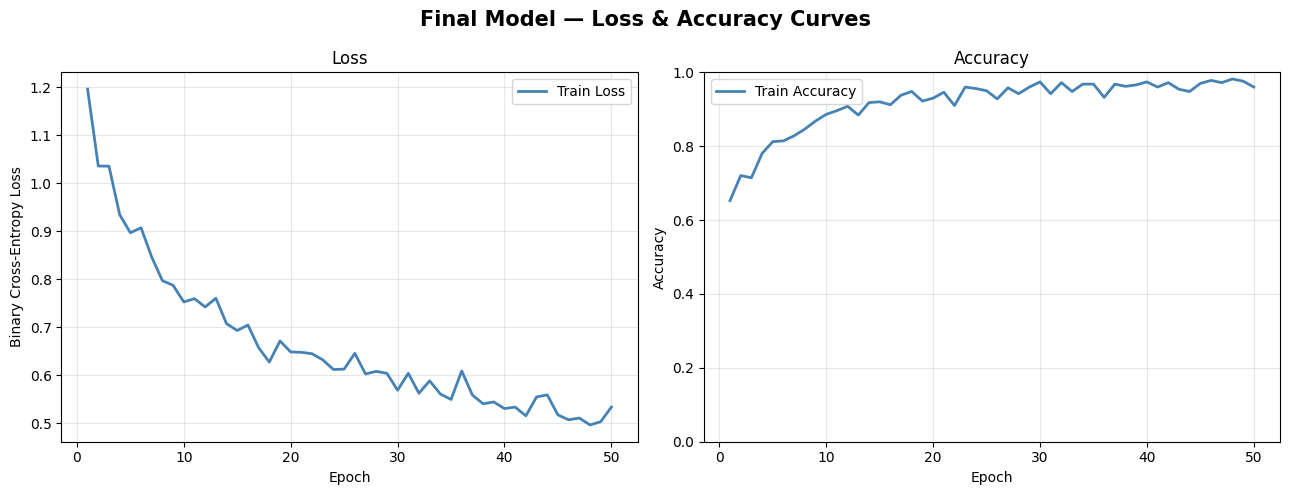

Saved: /content/final_model_loss_accuracy_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Final Model — Loss & Accuracy Curves', fontsize=15, fontweight='bold')

epochs_ran = range(1, len(final_history.history['loss']) + 1)

# Loss
axes[0].plot(epochs_ran, final_history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, final_history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/final_model_loss_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/final_model_loss_accuracy_curves.png")


## 7. Final Evaluation on Hold-Out Test Set

Loading final model: /content/final_resnet50_all_data.keras
Found 105 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step

  FINAL TEST SET RESULTS
  Recall (malignant) : 0.8889   <-- PRIORITY METRIC
  Recall (benign)    : 0.9420
  Precision          : 0.8889
  Accuracy           : 0.9238
  AUC                : 0.9656
  Loss               : 0.6946
  F1 (macro)         : 0.9155
  F1 (weighted)      : 0.9238
  F1 (benign   )     : 0.9420
  F1 (malignant)     : 0.8889

  -> The model correctly identifies 88.9% of actual malignant cases in the held-out test set (this is the number that matters most).

Classification Report:
              precision    recall  f1-score   support

      benign       0.94      0.94      0.94        69
   malignant       0.89      0.89      0.89        36

    accuracy                           0.92       105
   macro avg       0.92      0.92      0.92       105
weighted avg       0.92      0.92      0.92       105



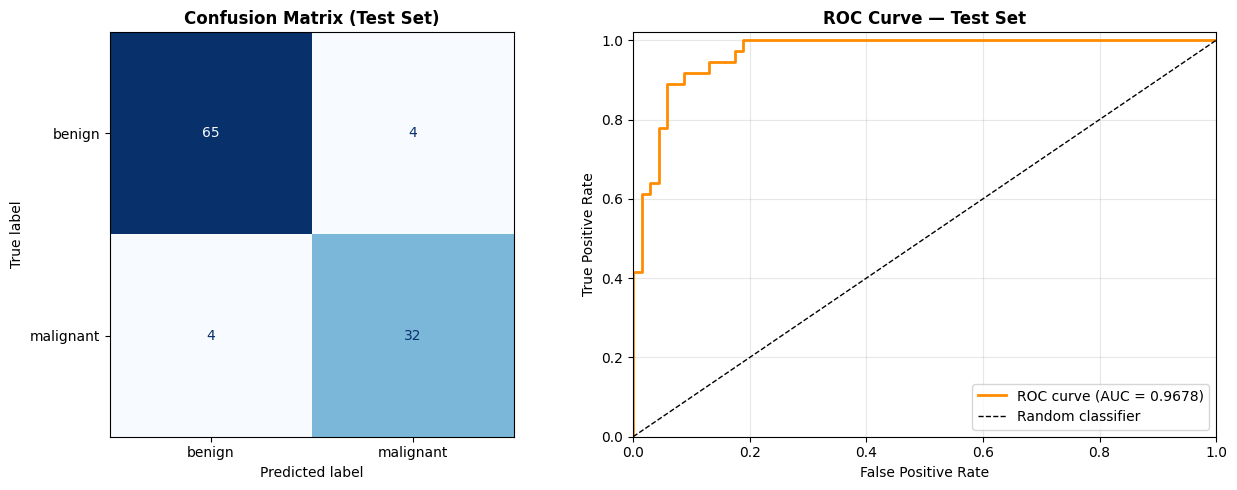

Saved: /content/test_evaluation.png


In [ ]:
# Use the final model trained on ALL k-fold data
print(f"Loading final model: {final_model_path}")
best_model = load_model(final_model_path)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES,
    shuffle=False
)

y_proba = best_model.predict(test_gen, verbose=1).ravel()
y_true  = test_gen.classes
y_pred  = (y_proba >= 0.5).astype(int)

test_loss, test_acc, test_auc, test_prec, test_rec = best_model.evaluate(test_gen, verbose=0)
test_f1_macro    = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
test_f1_perclass = f1_score(y_true, y_pred, average=None)

test_recall_perclass = recall_score(y_true, y_pred, average=None)

print("\n" + "="*55)
print("  FINAL TEST SET RESULTS")
print("="*55)
print(f"  Recall (malignant) : {test_rec:.4f}   <-- PRIORITY METRIC")
print(f"  Recall (benign)    : {test_recall_perclass[0]:.4f}")
print(f"  Precision          : {test_prec:.4f}")
print(f"  Accuracy           : {test_acc:.4f}")
print(f"  AUC                : {test_auc:.4f}")
print(f"  Loss               : {test_loss:.4f}")
print(f"  F1 (macro)         : {test_f1_macro:.4f}")
print(f"  F1 (weighted)      : {test_f1_weighted:.4f}")
for cls_name, f1 in zip(CLASS_NAMES, test_f1_perclass):
    print(f"  F1 ({cls_name:<9})     : {f1:.4f}")
print("="*55)
print(f"\n  -> The model correctly identifies {test_rec*100:.1f}% of actual malignant "
      f"cases in the held-out test set (this is the number that matters most).")
print("="*55)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = roc_auc_score(y_true, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/test_evaluation.png")


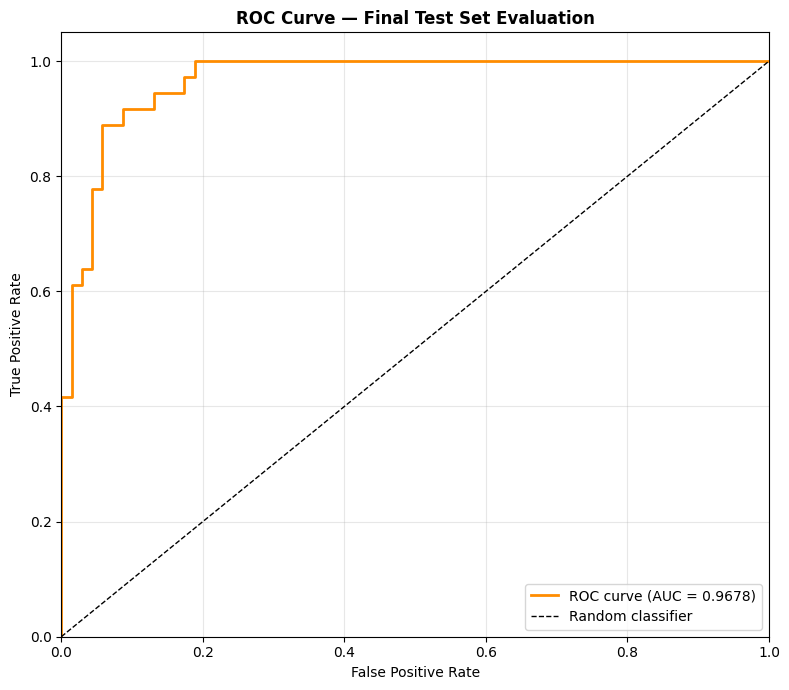

Saved: /content/final_test_roc_curve.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = roc_auc_score(y_true, y_proba)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Test Set Evaluation', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/final_test_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/final_test_roc_curve.png")